CRICKET OBJECT DETECTION - COMPLETE PIPELINE WITH VISUALIZATION

[1/7] Loading labels...

[2/7] Extracting hand-crafted features...
 Processing image 20/305...
 Processing image 40/305...
 Processing image 60/305...
 Processing image 80/305...
 Processing image 100/305...
 Processing image 120/305...
 Processing image 140/305...
 Processing image 160/305...
 Processing image 180/305...
 Processing image 200/305...
 Processing image 220/305...
 Processing image 240/305...
 Processing image 260/305...
 Processing image 280/305...
 Processing image 300/305...

[2.5/7] Saving Feature CSV...

✓ Train set: 15232 samples
✓ Test set: 4288 samples

[3/7] Training model...

[4/7] Evaluating TRAIN SET...

TRAIN SET - PERFORMANCE METRICS

📊 OVERALL METRICS:
  Accuracy:  0.9968
  Precision: 0.9969
  Recall:    0.9968
  F1-Score:  0.9969

🎯 PER-CLASS METRICS:
  Class           Precision    Recall       F1-Score     Support   
  -----------------------------------------------------------------
  No O

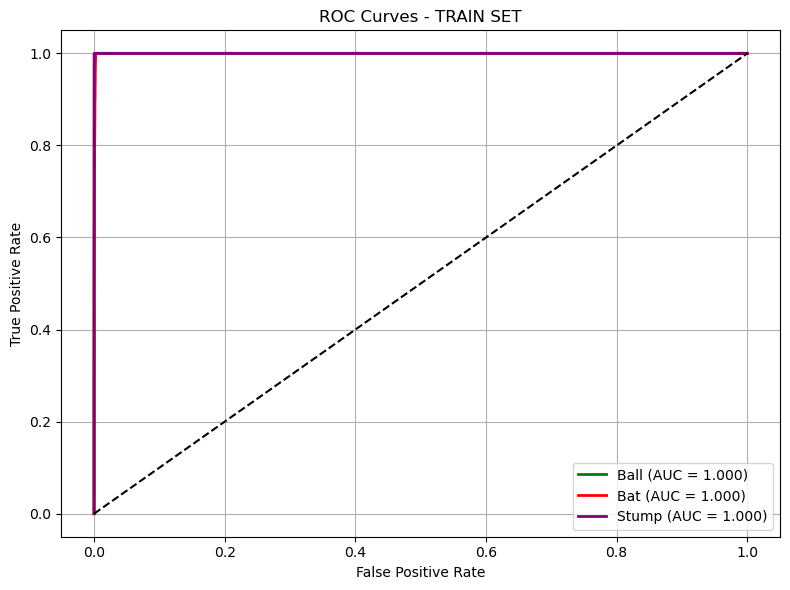


[ROC] Generating ROC curves for TEST SET...


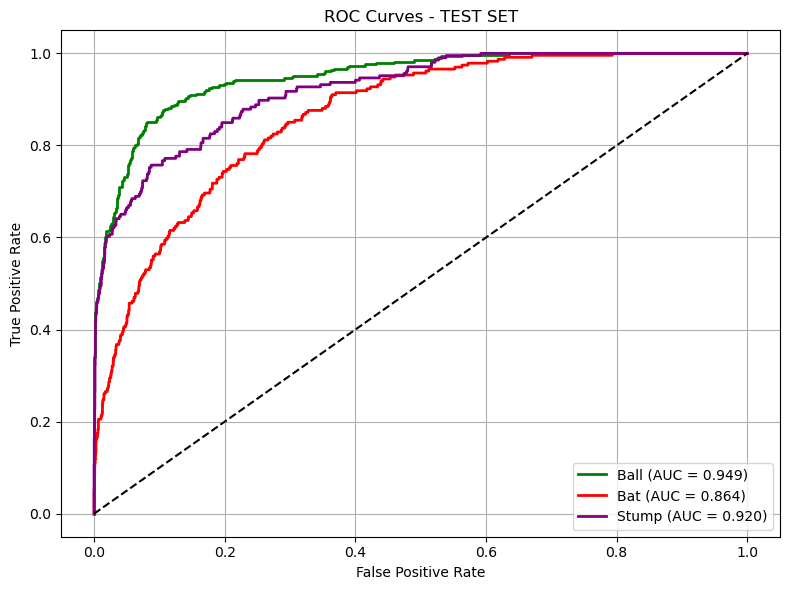


[5/7] Generating Visualized Images...

[VISUALIZATION] Generating images for: training_images...
✓ Saved 238 processed images to processed_images\training_images

[VISUALIZATION] Generating images for: testing_images...
✓ Saved 67 processed images to processed_images\testing_images

✓ Metrics exported to: performance_metrics_v2.csv

[6/7] Generating predictions CSV...
✓ Predictions saved to: predictions_output_v2.csv

✓ Model saved to: model_cricket_v2.pkl

[7/7] Pipeline completed!

✓ Pipeline execution completed!


In [10]:
"""
Cricket Object Detection - Complete Pipeline with Visualizations
=====================================================================

Hand-Crafted Feature Engineering Approach
Project: Ball, Bat, Stump Detection (8x8 Grid Classification)

INCLUDES:
✓ Complete model training & Metrics
✓ Visualized Output Generation (Grid Overlays)
✓ Predictions CSV & Model Saving

REQUIRED DELIVERABLE: Performance Metrics & Processed Images
"""

import pandas as pd
import numpy as np
import cv2
import os
import pickle
import warnings
from pathlib import Path
from collections import defaultdict
from skimage.feature import local_binary_pattern
from scipy import stats

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support,
    f1_score, precision_score, recall_score,
    roc_curve, auc
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import shutil

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    'image_dir': 'Dataset_Final',
    'label_file': 'Dataset_labelsf.xlsx',
    'grid_rows': 8,
    'grid_cols': 8,
    'image_width': 800,
    'image_height': 600,
    'model_name': 'model_cricket_v2.pkl',
    'predictions_csv': 'predictions_output_v2.csv',
    'metrics_csv': 'performance_metrics_v2.csv',
    'features_csv': 'extracted_features.csv',
    # --- NEW CONFIG FOR VISUALIZATION ---
    'processed_dir': 'processed_images',
    'train_vis_dir': 'training_images',
    'test_vis_dir': 'testing_images',
    'team_name': 'cricket',
    'random_seed': 42,
    'test_size': 0.2,
}

# ============================================================================
# FEATURE EXTRACTION CLASS
# ============================================================================

class CricketGridFeatureExtractor:
    """
    Extracts hand-crafted features from grid cells.
    """

    def __init__(self, grid_rows=8, grid_cols=8):
        self.grid_rows = grid_rows
        self.grid_cols = grid_cols
        self.cell_height = 600 // grid_rows
        self.cell_width = 800 // grid_cols

    def extract_grid_cell(self, image, cell_id):
        row = cell_id // self.grid_cols
        col = cell_id % self.grid_cols
        y_start = row * self.cell_height
        y_end = (row + 1) * self.cell_height
        x_start = col * self.cell_width
        x_end = (col + 1) * self.cell_width
        cell = image[y_start:y_end, x_start:x_end]
        return cell

    def compute_color_histogram_features(self, cell):
        hsv = cv2.cvtColor(cell, cv2.COLOR_BGR2HSV)
        features = []
        h_hist = cv2.calcHist([hsv], [0], None, [16], [0, 180])
        s_hist = cv2.calcHist([hsv], [1], None, [16], [0, 256])
        v_hist = cv2.calcHist([hsv], [2], None, [16], [0, 256])
        features.extend(h_hist.flatten() / (h_hist.sum() + 1e-6))
        features.extend(s_hist.flatten() / (s_hist.sum() + 1e-6))
        features.extend(v_hist.flatten() / (v_hist.sum() + 1e-6))
        h_mean, h_std = hsv[:, :, 0].mean(), hsv[:, :, 0].std()
        s_mean, s_std = hsv[:, :, 1].mean(), hsv[:, :, 1].std()
        v_mean, v_std = hsv[:, :, 2].mean(), hsv[:, :, 2].std()
        features.extend([h_mean, h_std, s_mean, s_std, v_mean, v_std])
        return np.array(features)

    def compute_edge_features(self, cell):
        gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
        features = []
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        sobel_mag = np.sqrt(sobelx ** 2 + sobely ** 2)
        features.extend([sobel_mag.mean(), sobel_mag.std(), sobel_mag.max(), np.percentile(sobel_mag, 75)])
        edges = cv2.Canny(gray, 50, 150)
        edge_ratio = edges.sum() / (edges.size * 255)
        features.append(edge_ratio)
        angles = np.arctan2(sobely, sobelx)
        angle_hist = np.histogram(angles, bins=8, range=(-np.pi, np.pi))[0]
        features.extend(angle_hist / (angle_hist.sum() + 1e-6))
        return np.array(features)

    def compute_texture_features(self, cell):
        gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
        features = []
        for radius in [1, 2, 3]:
            lbp = local_binary_pattern(gray, 8, radius, method='uniform')
            lbp_hist = np.histogram(lbp.ravel(), bins=59, range=(0, 59))[0]
            features.extend(lbp_hist / (lbp_hist.sum() + 1e-6))
        return np.array(features)

    def compute_shape_features(self, cell):
        gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
        features = []
        try:
            _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            moments = cv2.moments(binary)
            hu_moments = cv2.HuMoments(moments).flatten()
            features.extend(hu_moments)
        except:
            features.extend(np.zeros(7))
        cnts = cv2.findContours(gray, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        contours = cnts[1] if len(cnts) == 3 else cnts[0]
        if len(contours) > 0:
            features.append(len(contours))
            areas = [cv2.contourArea(c) for c in contours]
            features.extend([np.mean(areas), np.std(areas) if len(areas) > 1 else 0])
            largest_contour = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest_contour)
            perimeter = cv2.arcLength(largest_contour, True)
            circularity = 4 * np.pi * area / (perimeter ** 2 + 1e-6)
            features.extend([area, perimeter, circularity])
        else:
            features.extend(np.zeros(8))
        return np.array(features)

    def compute_statistical_features(self, cell):
        gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
        features = []
        pixel_values = gray.flatten()
        features.extend([
            pixel_values.mean(), pixel_values.std(), pixel_values.min(),
            pixel_values.max(), np.median(pixel_values),
            stats.skew(pixel_values), stats.kurtosis(pixel_values),
        ])
        features.extend(np.percentile(pixel_values, [25, 50, 75]))
        return np.array(features)

    def extract_all_features(self, image_path, cell_id):
        image = cv2.imread(image_path)
        if image is None: return None
        cell = self.extract_grid_cell(image, cell_id)
        features = []
        features.extend(self.compute_color_histogram_features(cell))
        features.extend(self.compute_edge_features(cell))
        features.extend(self.compute_texture_features(cell))
        features.extend(self.compute_shape_features(cell))
        features.extend(self.compute_statistical_features(cell))
        return np.array(features)


# ============================================================================
# PERFORMANCE METRICS CLASS
# ============================================================================

class PerformanceMetricsCalculator:
    def __init__(self, class_names=None):
        if class_names is None:
            self.class_names = {0: 'No Object', 1: 'Ball', 2: 'Bat', 3: 'Stump'}
        else:
            self.class_names = class_names

    def calculate_metrics(self, y_true, y_pred, dataset_name="Dataset"):
        metrics = {}
        metrics['accuracy'] = accuracy_score(y_true, y_pred)
        metrics['precision'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        metrics['recall'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        metrics['f1'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['f1_micro'] = f1_score(y_true, y_pred, average='micro', zero_division=0)

        precision_per_class, recall_per_class, f1_per_class, support = \
            precision_recall_fscore_support(y_true, y_pred, zero_division=0)

        metrics['per_class'] = {}
        for class_id in range(len(self.class_names)):
            metrics['per_class'][self.class_names[class_id]] = {
                'precision': precision_per_class[class_id],
                'recall': recall_per_class[class_id],
                'f1': f1_per_class[class_id],
                'support': int(support[class_id])
            }
        metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred)
        metrics['classification_report'] = classification_report(
            y_true, y_pred, target_names=list(self.class_names.values()), zero_division=0
        )
        return metrics

    def print_metrics(self, metrics, dataset_name="Dataset"):
        print(f"\n{'=' * 70}")
        print(f"{dataset_name.upper()} - PERFORMANCE METRICS")
        print(f"{'=' * 70}")
        print(f"\n📊 OVERALL METRICS:")
        print(f"  Accuracy:  {metrics['accuracy']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall:    {metrics['recall']:.4f}")
        print(f"  F1-Score:  {metrics['f1']:.4f}")

        print(f"\n🎯 PER-CLASS METRICS:")
        print(f"  {'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
        print(f"  {'-' * 65}")
        for class_name, class_metrics in metrics['per_class'].items():
            print(f"  {class_name:<15} {class_metrics['precision']:<12.4f} "
                  f"{class_metrics['recall']:<12.4f} {class_metrics['f1']:<12.4f} "
                  f"{class_metrics['support']:<10}")

        print(f"\n📈 DETAILED CLASSIFICATION REPORT:")
        print(metrics['classification_report'])

    def export_metrics_to_csv(self, metrics_train, metrics_test, output_file):
        rows = []
        for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'f1_macro', 'f1_micro']:
            rows.append({
                'Metric': metric_name.upper(), 'Type': 'Overall', 'Class': 'All',
                'Train': metrics_train[metric_name], 'Test': metrics_test[metric_name],
                'Difference': metrics_train[metric_name] - metrics_test[metric_name]
            })
        for class_name in self.class_names.values():
            train_class_metrics = metrics_train['per_class'][class_name]
            test_class_metrics = metrics_test['per_class'][class_name]
            for metric_type in ['precision', 'recall', 'f1']:
                rows.append({
                    'Metric': metric_type.upper(), 'Type': 'Per-Class', 'Class': class_name,
                    'Train': train_class_metrics[metric_type], 'Test': test_class_metrics[metric_type],
                    'Difference': train_class_metrics[metric_type] - test_class_metrics[metric_type]
                })
        df = pd.DataFrame(rows)
        df.to_csv(output_file, index=False)
        print(f"\n✓ Metrics exported to: {output_file}")
        return df

# ============================================================================
# MAIN PIPELINE CLASS
# ============================================================================

class CricketDetectionPipeline:
    def __init__(self, config):
        self.config = config
        self.extractor = CricketGridFeatureExtractor(
            grid_rows=config['grid_rows'],
            grid_cols=config['grid_cols']
        )
        self.scaler = StandardScaler()
        self.model = None
        self.metrics_calculator = PerformanceMetricsCalculator()

    def load_labels(self):
        print("\n[1/7] Loading labels...")
        df = pd.read_excel(self.config['label_file'])
        return df

    def prepare_dataset(self, df, save_csv=True):
        output_path = self.config.get('features_csv', 'extracted_features.csv')
        print("\n[2/7] Extracting hand-crafted features...")
        X = []
        y = []
        image_names = []
        cell_ids = []

        image_groups = df.groupby('ImageName')
        total_images = len(image_groups)

        for idx, (image_name, group) in enumerate(image_groups, 1):
            image_path = os.path.join(self.config['image_dir'], image_name)
            if not os.path.exists(image_path):
                continue

            if idx % 20 == 0:
                print(f" Processing image {idx}/{total_images}...")

            for _, row in group.iterrows():
                cell_id = int(row['CellID'])
                label = int(row['y'])
                features = self.extractor.extract_all_features(image_path, cell_id)
                if features is not None:
                    X.append(features)
                    y.append(label)
                    image_names.append(image_name)
                    cell_ids.append(cell_id)

        X = np.array(X)
        y = np.array(y)
        return X, y, image_names, cell_ids

    def train_model(self, X_train, y_train):
        print("\n[3/7] Training model...")
        X_train_scaled = self.scaler.fit_transform(X_train)
        self.model = RandomForestClassifier(
            n_estimators=200, max_depth=25, min_samples_split=5,
            min_samples_leaf=2, max_features='sqrt', class_weight='balanced',
            random_state=self.config['random_seed'], n_jobs=-1, verbose=0
        )
        self.model.fit(X_train_scaled, y_train)
        return self.model

    def evaluate_model(self, model, X, y, dataset_name="Dataset"):
        print(f"\n[4/7] Evaluating {dataset_name}...")
        X_scaled = self.scaler.transform(X)
        y_pred = model.predict(X_scaled)
        metrics = self.metrics_calculator.calculate_metrics(y, y_pred, dataset_name)
        self.metrics_calculator.print_metrics(metrics, dataset_name)
        return metrics, y_pred

    # =========================================================================
    #  VISUALIZATION METHOD (UPDATED)
    # =========================================================================
    def visualize_predictions(self, image_names, cell_ids, predictions, subfolder_name):
        """
        Generates images with colored grid overlays based on predictions.
        Colors: Ball=Green, Bat=Red, Stump=Blue, Background=None
        """
        print(f"\n[VISUALIZATION] Generating images for: {subfolder_name}...")

        # Setup paths
        base_dir = self.config['processed_dir']
        output_dir = os.path.join(base_dir, subfolder_name)
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)

        # Colors (BGR Format for OpenCV)
        # Class 1 (Ball): Green (0, 255, 0)
        # Class 2 (Bat): Red (0, 0, 255)
        # Class 3 (Stump): Blue (255, 0, 0)
        # Grid Lines: Yellow (0, 255, 255)
        COLORS = {
            1: (0, 255, 0),
            2: (0, 0, 255),
            3: (255, 0, 0)
        }
        GRID_COLOR = (0, 255, 255) # Yellow

        unique_images = np.unique(image_names)
        
        for img_name in unique_images:
            # 1. Load Original Image
            src_path = os.path.join(self.config['image_dir'], img_name)
            if not os.path.exists(src_path):
                continue
            
            img = cv2.imread(src_path)
            img = cv2.resize(img, (self.config['image_width'], self.config['image_height']))
            overlay = img.copy()

            # 2. Get predictions for this image
            mask = np.array(image_names) == img_name
            img_preds = predictions[mask]
            img_cells = np.array(cell_ids)[mask]

            # 3. Draw Grid and Colors
            rows = self.config['grid_rows']
            cols = self.config['grid_cols']
            cell_w = self.config['image_width'] // cols
            cell_h = self.config['image_height'] // rows

            # Sort to ensure cell ID matches prediction index (safety check)
            sorted_indices = np.argsort(img_cells)
            img_cells = img_cells[sorted_indices]
            img_preds = img_preds[sorted_indices]

            for i, cell_id in enumerate(img_cells):
                pred_class = img_preds[i]
                
                # Calculate coordinates
                r = cell_id // cols
                c = cell_id % cols
                x1 = c * cell_w
                y1 = r * cell_h
                x2 = x1 + cell_w
                y2 = y1 + cell_h

                # Draw Color Overlay if Object Detected
                if pred_class in COLORS:
                    cv2.rectangle(overlay, (x1, y1), (x2, y2), COLORS[pred_class], -1)
                
                # Draw Grid Lines
                cv2.rectangle(img, (x1, y1), (x2, y2), GRID_COLOR, 1)

            # 4. Apply Alpha Blending (Transparency)
            alpha = 0.4  # Transparency factor
            cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)

            # 5. Save
            save_path = os.path.join(output_dir, f"processed_{img_name}")
            cv2.imwrite(save_path, img)
        
        print(f"✓ Saved {len(unique_images)} processed images to {output_dir}")

    def plot_roc_curves(self, model, X, y, dataset_name="Dataset"):
        print(f"\n[ROC] Generating ROC curves for {dataset_name}...")
        X_scaled = self.scaler.transform(X)
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_scaled)
        else:
            return
        
        classes = [1, 2, 3]
        y_bin = label_binarize(y, classes=[0, 1, 2, 3])[:, 1:]
        class_colors = {1: "green", 2: "red", 3: "purple"} # Plot colors
        
        plt.figure(figsize=(8, 6))
        for idx, class_id in enumerate(classes):
            fpr, tpr, _ = roc_curve(y_bin[:, idx], y_score[:, class_id])
            auc_val = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=class_colors[class_id],
                     label=f"{self.metrics_calculator.class_names[class_id]} (AUC = {auc_val:.3f})", linewidth=2)
        
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves - {dataset_name}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def generate_predictions_csv(self, image_names, cell_ids, predictions,
                                 train_test_labels, output_file):
        print(f"\n[6/7] Generating predictions CSV...")
        results = []
        image_unique = np.unique(image_names)

        for img_name in image_unique:
            mask = np.array(image_names) == img_name
            img_predictions = predictions[mask]
            img_cell_ids = np.array(cell_ids)[mask]
            img_train_test = train_test_labels[mask][0]

            sorted_indices = np.argsort(img_cell_ids)
            img_predictions = img_predictions[sorted_indices]

            row = {'ImageFileName': img_name, 'TrainOrTest': img_train_test}
            for cell_idx, pred in enumerate(img_predictions):
                row[f'c{cell_idx + 1:02d}'] = int(pred)
            results.append(row)

        columns = ['ImageFileName', 'TrainOrTest'] + [f'c{i:02d}' for i in range(1, 65)]
        results_df = pd.DataFrame(results)
        results_df = results_df[columns]
        results_df.to_csv(output_file, index=False)
        print(f"✓ Predictions saved to: {output_file}")
        return results_df

    def save_model(self, model_path):
        with open(model_path, 'wb') as f:
            pickle.dump({'model': self.model, 'scaler': self.scaler, 'config': self.config}, f)
        print(f"\n✓ Model saved to: {model_path}")

    def run_pipeline(self):
        print("=" * 70)
        print("CRICKET OBJECT DETECTION - COMPLETE PIPELINE WITH VISUALIZATION")
        print("=" * 70)

        df = self.load_labels()

        # Split logic
        unique_images = df['ImageName'].unique()
        np.random.seed(self.config['random_seed'])
        test_mask = np.random.rand(len(unique_images)) < self.config['test_size']
        test_images = set(unique_images[test_mask])
        train_images = set(unique_images[~test_mask])

        # Prepare dataset
        X, y, image_names, cell_ids = self.prepare_dataset(df, save_csv=False)

        # Split Data
        train_mask = np.array([img in train_images for img in image_names])
        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[~train_mask], y[~train_mask]

        # Metadata for splitting visualizaion
        train_image_names = np.array(image_names)[train_mask]
        train_cell_ids = np.array(cell_ids)[train_mask]
        test_image_names = np.array(image_names)[~train_mask]
        test_cell_ids = np.array(cell_ids)[~train_mask]

        # Save Feature CSV logic (Condensed)
        print(f"\n[2.5/7] Saving Feature CSV...")
        split_labels = ['Train' if is_train else 'Test' for is_train in train_mask]
        df_meta = pd.DataFrame({'ImageName': image_names, 'CellID': cell_ids, 'Label': y, 'TrainOrTest': split_labels})
        feat_cols = [f"feat_{i}" for i in range(X.shape[1])]
        df_final = pd.concat([df_meta, pd.DataFrame(X, columns=feat_cols)], axis=1)
        df_final.to_csv(self.config['features_csv'], index=False)

        print(f"\n✓ Train set: {len(X_train)} samples")
        print(f"✓ Test set: {len(X_test)} samples")

        # Train & Evaluate
        model = self.train_model(X_train, y_train)
        train_metrics, y_pred_train = self.evaluate_model(model, X_train, y_train, "TRAIN SET")
        test_metrics, y_pred_test = self.evaluate_model(model, X_test, y_test, "TEST SET")
        
        self.plot_roc_curves(model, X_train, y_train, "TRAIN SET")
        self.plot_roc_curves(model, X_test, y_test, "TEST SET")

        # ====================================================================
        # NEW STEP: GENERATE VISUALIZATIONS
        # ====================================================================
        print(f"\n[5/7] Generating Visualized Images...")
        self.visualize_predictions(train_image_names, train_cell_ids, y_pred_train, self.config['train_vis_dir'])
        self.visualize_predictions(test_image_names, test_cell_ids, y_pred_test, self.config['test_vis_dir'])
        # ====================================================================

        # Export metrics
        metrics_df = self.metrics_calculator.export_metrics_to_csv(train_metrics, test_metrics, self.config['metrics_csv'])

        # Combine for CSV Output
        all_image_names = np.concatenate([train_image_names, test_image_names])
        all_cell_ids = np.concatenate([train_cell_ids, test_cell_ids])
        all_predictions = np.concatenate([y_pred_train, y_pred_test])
        all_train_test = np.concatenate([np.array(['train']*len(y_pred_train)), np.array(['test']*len(y_pred_test))])

        predictions_df = self.generate_predictions_csv(all_image_names, all_cell_ids, all_predictions, all_train_test, self.config['predictions_csv'])
        self.save_model(self.config['model_name'])

        print(f"\n[7/7] Pipeline completed!")
        print("=" * 70)
        return {'train_metrics': train_metrics, 'test_metrics': test_metrics}

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    pipeline = CricketDetectionPipeline(CONFIG)
    results = pipeline.run_pipeline()
    print("\n✓ Pipeline execution completed!")